In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gwpy.timeseries import TimeSeries
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.types import TimeSeries as PyCBCTimeSeries

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
# ------------------------------------------------------------
# Analysis configuration
# ------------------------------------------------------------
# In this notebook we choose:
#   - which gravitational-wave event to analyze
#   - which detector(s) to use
#   - how much data to download
#   - the sample rate and frequency range for filtering
#   - the small template-bank grid we will test later
#
# We start with GW150914

event_name = "GW150914"

# Detector list:
detectors = ["H1", "L1"]

# Reference GPS time for GW150914.
# We will use this to build a relative time axis and to measure
# recovered trigger offsets from the known event time.
event_time_gps = 1126259462.4

# Duration of data to analyze, in seconds.
# For a BBH event like GW150914, 32 s is enough to show:
#   - raw strain
#   - PSD estimation
#   - matched-filter recovery
duration = 32

# Sampling rate in Hz. 
# it preserves the signal content we need without making things too heavy.
sample_rate = 4096

# Low-frequency cutoff for PSD / matched filtering.
f_low = 20.0

# PSD estimation segment length in seconds.
# This controls the frequency resolution of the noise estimate.
psd_segment_length = 4

# Crop time in seconds after matched filtering.
# We remove edges because FFT-based matched filtering can produce
# wraparound / boundary artifacts near the start and end.
crop_seconds = 4

# Analysis window:
# start and end GPS times for the downloaded data segment.
# We center the segment on the event time.
start_time = int(event_time_gps - duration / 2)
end_time = int(event_time_gps + duration / 2)

# Small pedagogical template bank:
# each pair is (mass1, mass2) in solar masses.
# Our bank is small enough to allow us to demonstrate its use easily
mass_pairs = [
    (20, 20),
    (25, 20),
    (30, 30),
    (35, 30),
    (40, 35),
]

# Waveform model (approximant).
# TaylorT4 is a simple time-domain inspiral model 
approximant = "TaylorT4"

# Output directory name for saved plots/tables if we choose to export later.
output_dir = "results"

print("Event:", event_name)
print("Detectors:", detectors)
print("GPS window:", start_time, "to", end_time)
print("Duration (s):", duration)
print("Sample rate (Hz):", sample_rate)
print("Low-frequency cutoff (Hz):", f_low)
print("Number of templates:", len(mass_pairs))

Event: GW150914
Detectors: ['H1', 'L1']
GPS window: 1126259446 to 1126259478
Duration (s): 32
Sample rate (Hz): 4096
Low-frequency cutoff (Hz): 20.0
Number of templates: 5


In [3]:
# ------------------------------------------------------------
# Download real detector strain data from GWOSC
# ------------------------------------------------------------
# In this step we get real gravitational-wave detector data
# from the Gravitational Wave Open Science Center (GWOSC).
#
# The data returned by GWpy is a "Strain TimeSeries" object that
# contains:
#   - the detector strain values
#   - the sample rate
#   - the absolute GPS epoch (t0)
#
# We store the strain data for each detector in a dictionary
# so that later stages of the pipeline can easily access them.

strain_data = {}

for det in detectors:
    
    print(f"Downloading strain data for detector {det}...")
    
    # Get open data from GWOSC
    strain = TimeSeries.fetch_open_data(
        det,
        start_time,
        end_time,
        sample_rate=sample_rate,
        cache=True
    )
    
    # Store the strain object
    strain_data[det] = strain
    
    print(f"{det} data loaded")
    print("Sample rate:", strain.sample_rate)
    print("Number of samples:", len(strain))
    print("Start GPS time:", strain.t0)
    print()

print("All requested detectors loaded.")

H1 data loaded
Sample rate: 4096.0 Hz
Number of samples: 131072
Start GPS time: 1126259446.0 s

L1 data loaded
Sample rate: 4096.0 Hz
Number of samples: 131072
Start GPS time: 1126259446.0 s

All requested detectors loaded.


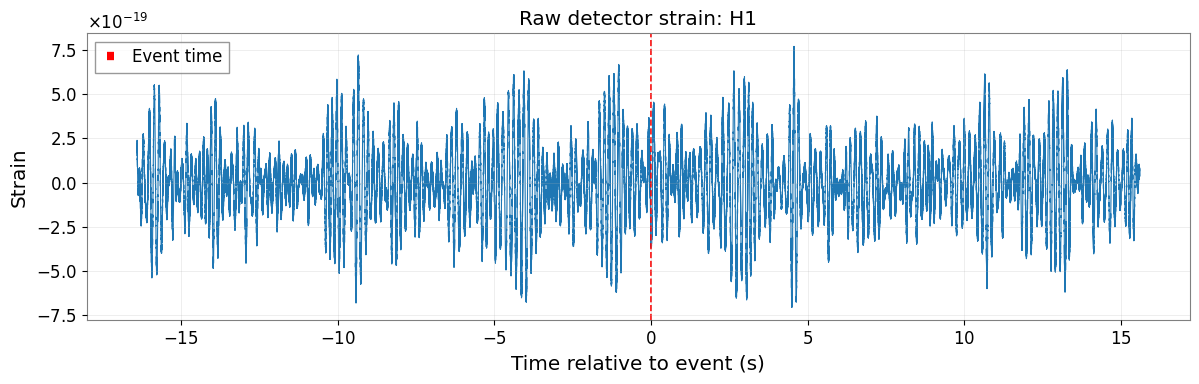

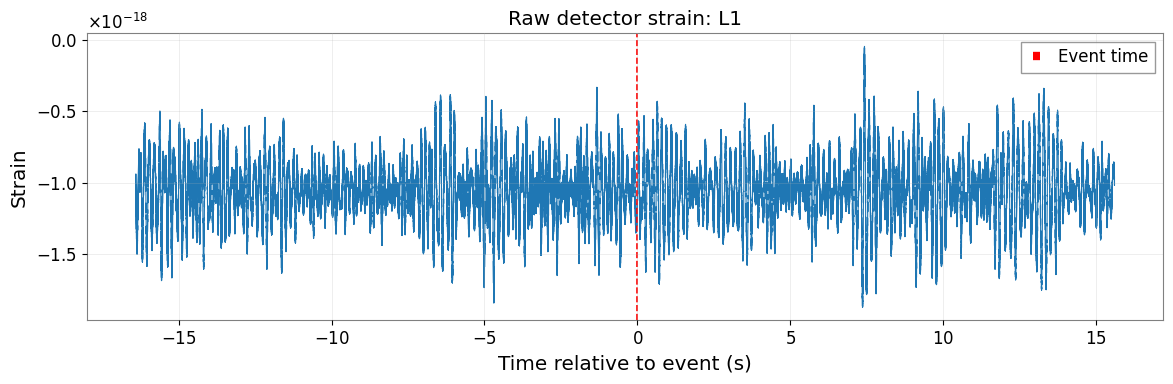

In [4]:
# ------------------------------------------------------------
# Build time axes and plot raw detector strain
# ------------------------------------------------------------
# We now inspect the real detector data in the time domain.
#
# For each detector we create:
#   1. an absolute GPS time axis
#   2. a relative time axis measured from the event reference time
#
# The relative axis is especially useful because it lets us see
# where the signal sits with respect to the known event time.
# Later, when we recover matched-filter peaks, we will compare
# those trigger times to this same reference.

for det in detectors:
    
    # Retrieve the GWpy strain object for this detector
    strain = strain_data[det]
    
    # Absolute GPS time axis
    # GWpy stores the start time in strain.t0 and the sample spacing
    # in strain.dt, so we can reconstruct the full time array.
    gps_times = strain.t0.value + np.arange(len(strain)) * strain.dt.value
    
    # Relative time axis with respect to the event/reference time
    rel_times = gps_times - event_time_gps
    
    # Plot raw strain as a function of relative time
    plt.figure(figsize=(12, 4))
    plt.plot(rel_times, strain.value, lw=0.8)
    plt.axvline(0, ls="--", lw=1.2, color="red", label="Event time")
    
    plt.xlabel("Time relative to event (s)")
    plt.ylabel("Strain")
    plt.title(f"Raw detector strain: {det}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [5]:
# ------------------------------------------------------------
# Convert GWpy strain to PyCBC TimeSeries
# ------------------------------------------------------------
# GWpy is very convenient for downloading and inspecting open data.
# PyCBC is very convenient for matched filtering and waveform analysis.
#
# So here we convert each detector's strain data from a GWpy object
# into a PyCBC TimeSeries, while explicitly preserving:
#   - the sample spacing (delta_t)
#   - the absolute GPS epoch
#
# Preserving the epoch is important because later we want matched-filter
# trigger times in physical GPS units

pycbc_data = {}

for det in detectors:
    
    # Get the GWpy strain object
    strain = strain_data[det]
    
    # Convert to a PyCBC TimeSeries
    # We pass:
    #   - the raw strain values
    #   - delta_t = sampling interval in seconds
    #   - epoch   = absolute GPS start time
    data = PyCBCTimeSeries(
        strain.value,
        delta_t=strain.dt.value,
        epoch=strain.t0.value
    )
    
    # Store the converted data
    pycbc_data[det] = data
    
    print(f"{det} converted to PyCBC TimeSeries")
    print("  Length:", len(data))
    print("  delta_t:", data.delta_t)
    print("  Start epoch (GPS):", data.start_time)
    print()

print("All detector streams converted successfully.")

H1 converted to PyCBC TimeSeries
  Length: 131072
  delta_t: 0.000244140625
  Start epoch (GPS): 1126259446

L1 converted to PyCBC TimeSeries
  Length: 131072
  delta_t: 0.000244140625
  Start epoch (GPS): 1126259446

All detector streams converted successfully.


In [6]:
# ------------------------------------------------------------
# Estimate the detector noise PSD
# ------------------------------------------------------------
# The Power Spectral Density (PSD) describes how detector noise
# is distributed across frequencies.
#
# Matched filtering requires a PSD because the filter weights
# frequencies according to how noisy the detector is.
#
# Steps:
#   1. Estimate PSD from the real detector data
#   2. Interpolate it to match the data frequency grid
#   3. Apply inverse spectrum truncation to stabilize the PSD

psd_data = {}

for det in detectors:
    
    data = pycbc_data[det]
    
    print(f"Estimating PSD for {det}...")
    
    # Estimate PSD using segments of the data
    psd = data.psd(psd_segment_length)
    
    # Interpolate PSD to match the frequency resolution
    psd = interpolate(psd, data.delta_f)
    
    # Smooth / condition the PSD
    psd = inverse_spectrum_truncation(
        psd,
        int(psd_segment_length * data.sample_rate),
        low_frequency_cutoff=f_low
    )
    
    # Store PSD
    psd_data[det] = psd
    
    print(f"{det} PSD estimated")
    print("Frequency bins:", len(psd))
    print()

print("PSD estimation complete.")

Estimating PSD for H1...
H1 PSD estimated
Frequency bins: 65537

Estimating PSD for L1...
L1 PSD estimated
Frequency bins: 65537

PSD estimation complete.


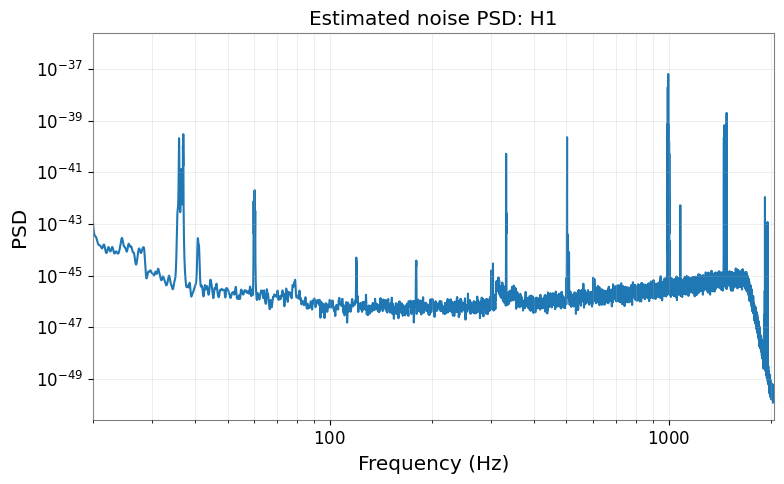

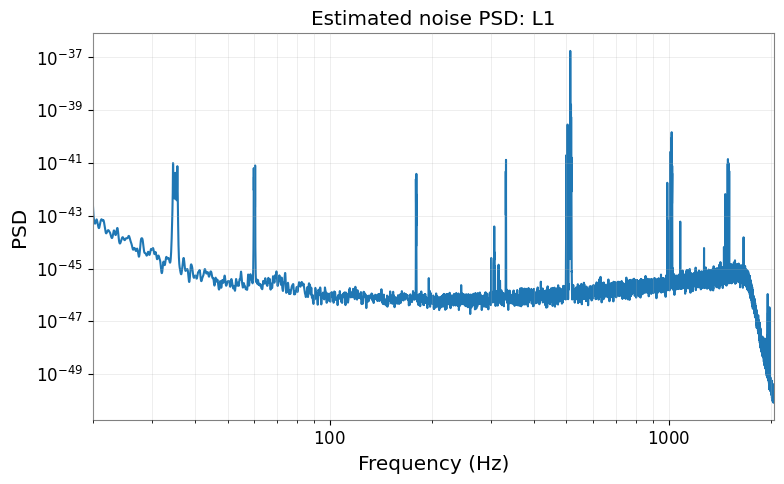

In [7]:
# ------------------------------------------------------------
# Plot the detector PSD
# ------------------------------------------------------------
# This plot shows the estimated noise Power Spectral Density (PSD)
# for the detector.
#
# We use log-log axes 

for det in detectors:
    
    psd = psd_data[det]
    
    plt.figure(figsize=(8, 5))
    plt.loglog(psd.sample_frequencies, psd, lw=1.5)
    
    plt.xlim(f_low, sample_rate / 2)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title(f"Estimated noise PSD: {det}")
    plt.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()

In [8]:
# ------------------------------------------------------------
# Whiten the detector data for visualization
# ------------------------------------------------------------
# Whitening rescales the strain so that frequencies with large noise
# are suppressed and frequencies in the sensitive band are emphasized.


whitened_data = {}

for det in detectors:
    
    strain = strain_data[det]
    
    # Whiten the GWpy strain data
    # fduration controls the whitening filter length in seconds.
    whitened = strain.whiten(fduration=4)
    
    # Store for later plotting / optional spectrograms
    whitened_data[det] = whitened
    
    print(f"{det} whitened successfully")
    print("Length:", len(whitened))
    print()

H1 whitened successfully
Length: 131072

L1 whitened successfully
Length: 131072



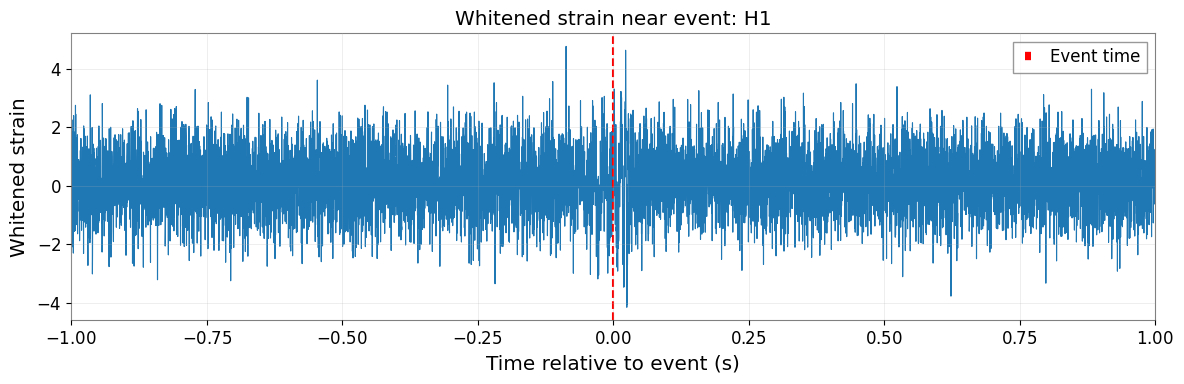

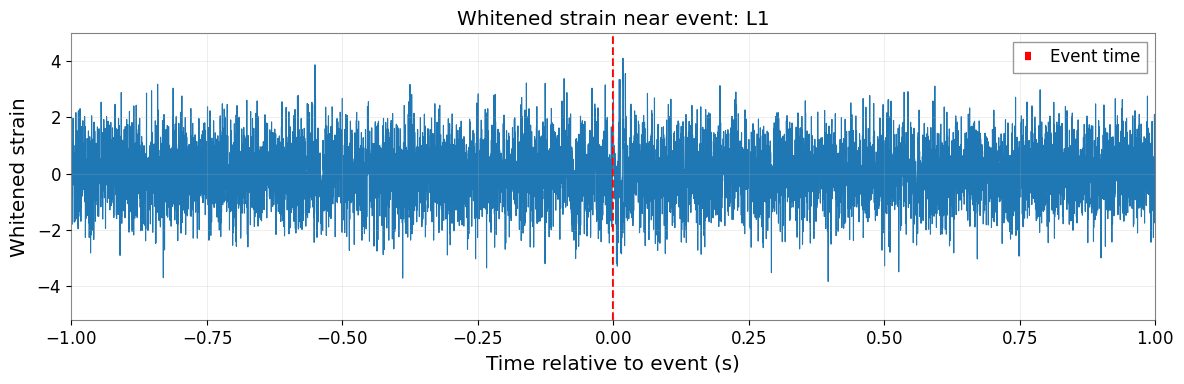

In [9]:
# ------------------------------------------------------------
# Plot whitened strain around the event time
# ------------------------------------------------------------
# After whitening, transient signals become easier to see
# because the detector noise has been flattened in frequency.
#
# We again plot using a relative time axis centered on the
# reference event time so we can visually inspect the region
# where the signal is expected to occur.

for det in detectors:

    whitened = whitened_data[det]

    # Build time axes
    gps_times = whitened.t0.value + np.arange(len(whitened)) * whitened.dt.value
    rel_times = gps_times - event_time_gps

    plt.figure(figsize=(12,4))
    plt.plot(rel_times, whitened.value, lw=0.8)
    plt.axvline(0, ls="--", color="red", label="Event time")

    plt.xlim(-1, 1)   # zoom into ±1 second around the event
    plt.xlabel("Time relative to event (s)")
    plt.ylabel("Whitened strain")
    plt.title(f"Whitened strain near event: {det}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Example template generated for masses (20, 20)
Template length: 7242
delta_t: 0.000244140625
Start time relative to merger: -1.768066406


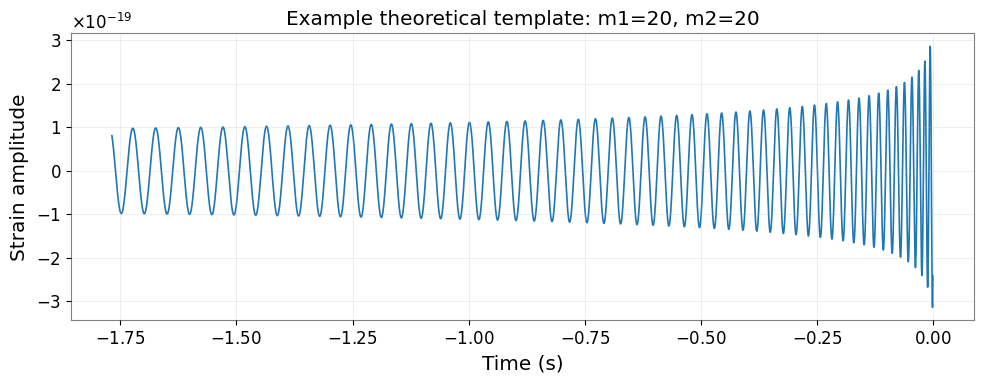

In [10]:
# ------------------------------------------------------------
# Generate and inspect one example waveform template
# ------------------------------------------------------------
# Before looping over the full template bank, we will generate 
# one theoretical compact-binary waveform and look at its shape.


m1, m2 = mass_pairs[0]

# Generate the plus-polarization waveform in the time domain
hp, hc = get_td_waveform(
    approximant=approximant,
    mass1=m1,
    mass2=m2,
    delta_t=1.0 / sample_rate,
    f_lower=f_low
)

print(f"Example template generated for masses ({m1}, {m2})")
print("Template length:", len(hp))
print("delta_t:", hp.delta_t)
print("Start time relative to merger:", hp.start_time)

# Build a time axis for plotting the template itself
template_times = hp.sample_times

plt.figure(figsize=(10, 4))
plt.plot(template_times, hp, lw=1.2)
plt.xlabel("Time (s)")
plt.ylabel("Strain amplitude")
plt.title(f"Example theoretical template: m1={m1}, m2={m2}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Prepared template length: 131072
Detector data length:     131072
Template delta_t:         0.000244140625
Data delta_t:             0.000244140625


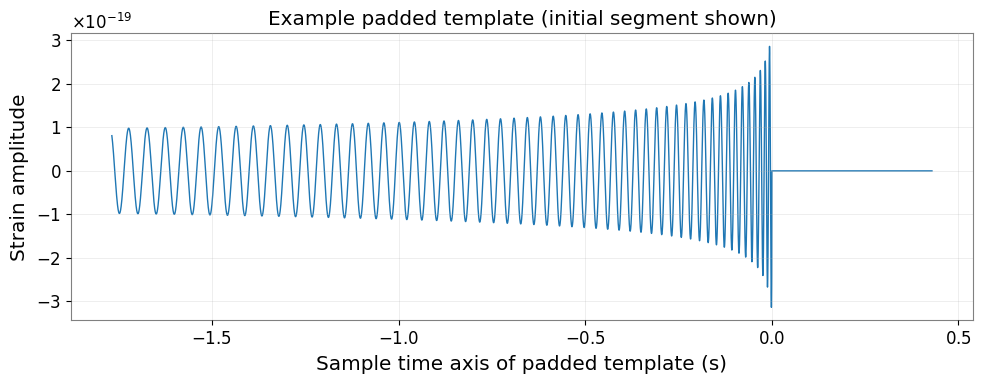

In [11]:
# ------------------------------------------------------------
# Prepare one example template so it matches the detector-data length
# ------------------------------------------------------------
# The raw waveform template returned by get_td_waveform is much shorter
# than the full detector data segment.
#
# For matched filtering, we want the template represented in the same
# overall time-series length convention as the detector data.


# Use H1 as the reference detector for sizing in this single-detector run
data = pycbc_data["H1"]

# Make a copy of the waveform so we do not modify the original hp object
template_example = hp.copy()

# Resize pads with zeros up to the detector-data length
template_example.resize(len(data))

print("Prepared template length:", len(template_example))
print("Detector data length:    ", len(data))
print("Template delta_t:        ", template_example.delta_t)
print("Data delta_t:            ", data.delta_t)

# Plot a short window of the padded template so we can still see the signal
plt.figure(figsize=(10, 4))
plt.plot(template_example.sample_times[:9000], template_example[:9000], lw=1.0)
plt.xlabel("Sample time axis of padded template (s)")
plt.ylabel("Strain amplitude")
plt.title("Example padded template (initial segment shown)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ------------------------------------------------------------
# Compute matched-filter SNR for the example template
# ------------------------------------------------------------
# The matched filter compares the theoretical waveform template
# against the real detector data using the detector PSD to weight
# frequencies according to the noise level.
#
# Output:
#   an SNR time series
#   the peak SNR value
#   the time of the peak

det = "H1"

data = pycbc_data[det]
psd = psd_data[det]
template = template_example

print("Running matched filter for example template...")

# Compute matched-filter SNR time series
snr = matched_filter(
    template,
    data,
    psd=psd,
    low_frequency_cutoff=f_low
)

# Crop edges to remove FFT wraparound artifacts
snr = snr.crop(crop_seconds, crop_seconds)

# Absolute value of SNR
abs_snr = abs(snr)

# Find peak
peak_index = np.argmax(abs_snr)
peak_snr = abs_snr[peak_index]
peak_time = snr.sample_times[peak_index]

print("Peak SNR:", float(peak_snr))
print("Peak time (GPS):", float(peak_time))
print("Offset from event (s):", float(peak_time - event_time_gps))

Running matched filter for example template...
Peak SNR: 8.27086902427402
Peak time (GPS): 1126259460.6567383
Offset from event (s): -1.7432618141174316


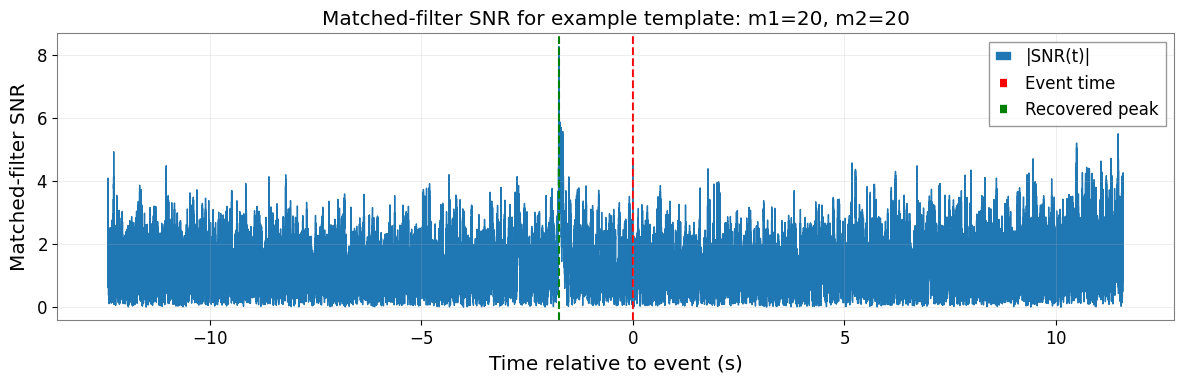

In [13]:
# ------------------------------------------------------------
# Plot the matched-filter SNR time series for the example template
# ------------------------------------------------------------
# This is the key matched-filter diagnostic plot.
#
# We show:
#   - the absolute SNR as a function of time
#   - the known event time
#   - the recovered peak time for this template
#
# Since this is only one template from the bank, the peak will not
# necessarily line up perfectly with the true event time.

# Build relative time axis for the cropped SNR series
snr_times_rel = np.array(snr.sample_times) - event_time_gps

plt.figure(figsize=(12, 4))
plt.plot(snr_times_rel, abs_snr, lw=1.0, label="|SNR(t)|")
plt.axvline(0, ls="--", color="red", label="Event time")
plt.axvline(float(peak_time - event_time_gps), ls="--", color="green", label="Recovered peak")

plt.xlabel("Time relative to event (s)")
plt.ylabel("Matched-filter SNR")
plt.title(f"Matched-filter SNR for example template: m1={m1}, m2={m2}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# ------------------------------------------------------------
# Run matched-filter search over the template bank for ALL detectors
# ------------------------------------------------------------
# For each detector and each template we:
#   1. Generate the waveform template
#   2. Resize it to match the detector data length
#   3. Compute the matched-filter SNR
#   4. Find the peak SNR and time
#   5. Store the trigger in a results table

results_table = []

best_overall_snr = -np.inf
best_template = None
best_snr_series = None
best_peak_time = None
best_masses = None
best_detector = None

for det in detectors:

    print(f"\nRunning template bank search for detector {det}")

    data = pycbc_data[det]
    psd = psd_data[det]

    for m1, m2 in mass_pairs:

        print(f"  Processing template m1={m1}, m2={m2}")

        # Generate waveform template
        hp, hc = get_td_waveform(
            approximant=approximant,
            mass1=m1,
            mass2=m2,
            delta_t=1.0 / sample_rate,
            f_lower=f_low
        )

        # Prepare template
        template = hp.copy()
        template.resize(len(data))

        # Compute matched filter
        snr = matched_filter(
            template,
            data,
            psd=psd,
            low_frequency_cutoff=f_low
        )

        # Remove FFT edge artifacts
        snr = snr.crop(crop_seconds, crop_seconds)

        abs_snr = abs(snr)

        peak_index = np.argmax(abs_snr)
        peak_snr = float(abs_snr[peak_index])
        peak_time = float(snr.sample_times[peak_index])
        timing_offset = peak_time - event_time_gps

        # Store trigger
        results_table.append({
            "detector": det,
            "mass1": m1,
            "mass2": m2,
            "peak_snr": peak_snr,
            "peak_time_gps": peak_time,
            "timing_offset_seconds": timing_offset
        })

        # Track best overall trigger
        if peak_snr > best_overall_snr:
            best_overall_snr = peak_snr
            best_template = template
            best_snr_series = snr
            best_peak_time = peak_time
            best_masses = (m1, m2)
            best_detector = det

print("\nMulti-detector template bank search complete.")


Running template bank search for detector H1
  Processing template m1=20, m2=20
  Processing template m1=25, m2=20
  Processing template m1=30, m2=30
  Processing template m1=35, m2=30
  Processing template m1=40, m2=35

Running template bank search for detector L1
  Processing template m1=20, m2=20
  Processing template m1=25, m2=20
  Processing template m1=30, m2=30
  Processing template m1=35, m2=30
  Processing template m1=40, m2=35

Multi-detector template bank search complete.


In [15]:
# ------------------------------------------------------------
# Convert results to DataFrame and rank templates
# ------------------------------------------------------------

results_df = pd.DataFrame(results_table)

# Sort by peak SNR (descending)
results_df = results_df.sort_values("peak_snr", ascending=False)

# Add rank column
results_df["rank"] = np.arange(1, len(results_df) + 1)

print("\nTemplate ranking by SNR:\n")
display(results_df)


Template ranking by SNR:



,detector,mass1,mass2,peak_snr,peak_time_gps,timing_offset_seconds,rank
3,H1,35,30,10.992158,1.126259e+09,-0.697852,1
4,H1,40,35,10.471560,1.126259e+09,-0.537695,2
2,H1,30,30,9.736587,1.126259e+09,-0.811865,3
1,H1,25,20,9.151704,1.126259e+09,-1.417578,4
0,H1,20,20,8.270869,1.126259e+09,-1.743262,5
8,L1,35,30,6.963181,1.126259e+09,-0.705664,6
7,L1,30,30,6.945818,1.126259e+09,-0.820654,7
6,L1,25,20,6.661882,1.126259e+09,-1.424658,8
9,L1,40,35,5.401652,1.126259e+09,-0.548926,9
5,L1,20,20,5.028777,1.126259e+09,-12.130957,10


In [19]:
# ------------------------------------------------------------
# Print summary of the best-matching template
# ------------------------------------------------------------

print("Best template found:\n")
print("Detector:", best_detector)
print("Mass1:", best_masses[0])
print("Mass2:", best_masses[1])
print("Peak SNR:", best_overall_snr)
print("Peak GPS time:", best_peak_time)
print("Offset from event (s):", best_peak_time - event_time_gps)

Best template found:

Detector: H1
Mass1: 35
Mass2: 30
Peak SNR: 10.992157984371085
Peak GPS time: 1126259461.7021484
Offset from event (s): -0.6978516578674316


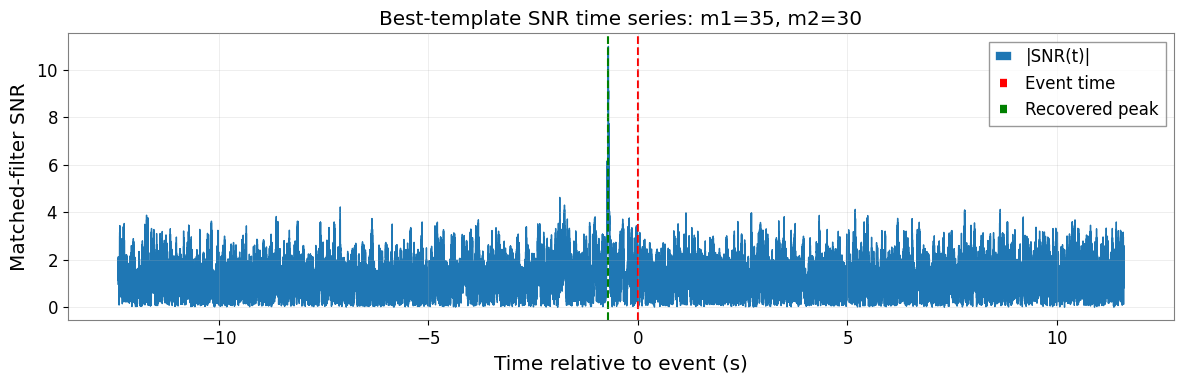

In [20]:
# ------------------------------------------------------------
# Plot the best matched-filter SNR time series
# ------------------------------------------------------------
# This is the main search result for the notebook.
#
# We plot the absolute SNR time series for the best-performing
# template in the bank, and mark:
#   - the reference event time
#   - the recovered peak time from the search
#
# This shows where the strongest matched-filter response occurs.

best_abs_snr = abs(best_snr_series)
best_times_rel = np.array(best_snr_series.sample_times) - event_time_gps
best_peak_rel = best_peak_time - event_time_gps

plt.figure(figsize=(12, 4))
plt.plot(best_times_rel, best_abs_snr, lw=1.0, label="|SNR(t)|")
plt.axvline(0, ls="--", color="red", label="Event time")
plt.axvline(best_peak_rel, ls="--", color="green", label="Recovered peak")

plt.xlabel("Time relative to event (s)")
plt.ylabel("Matched-filter SNR")
plt.title(
    f"Best-template SNR time series: m1={best_masses[0]}, m2={best_masses[1]}"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

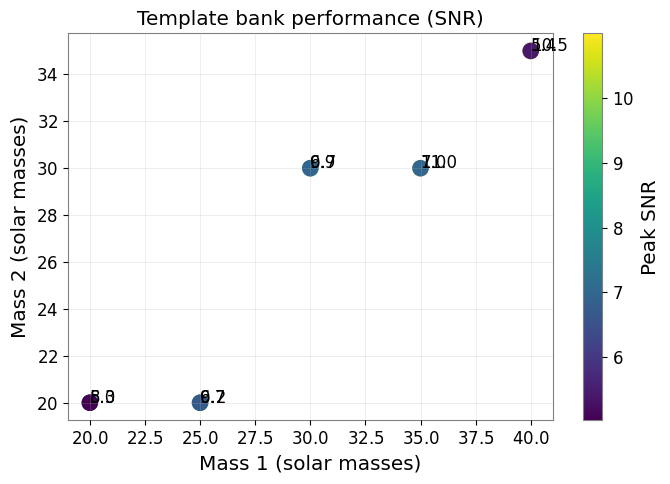

In [21]:
# ------------------------------------------------------------
# Plot SNR vs template masses
# ------------------------------------------------------------
# This visualization shows how the matched-filter response
# changes across the template bank.

plt.figure(figsize=(7,5))

plt.scatter(
    results_df["mass1"],
    results_df["mass2"],
    c=results_df["peak_snr"],
    s=120
)

for _, row in results_df.iterrows():
    plt.text(row["mass1"], row["mass2"], f"{row['peak_snr']:.1f}")

plt.xlabel("Mass 1 (solar masses)")
plt.ylabel("Mass 2 (solar masses)")
plt.title("Template bank performance (SNR)")
plt.grid(alpha=0.3)

cbar = plt.colorbar()
cbar.set_label("Peak SNR")

plt.tight_layout()
plt.show()

In [22]:
# ------------------------------------------------------------
# Find the best trigger for each detector
# ------------------------------------------------------------

detector_best = (
    results_df
    .sort_values("peak_snr", ascending=False)
    .groupby("detector")
    .first()
    .reset_index()
)

print("Best trigger per detector:\n")
display(detector_best)

Best trigger per detector:



,detector,mass1,mass2,peak_snr,peak_time_gps,timing_offset_seconds,rank
0,H1,35,30,10.992158,1.126259e+09,-0.697852,1
1,L1,35,30,6.963181,1.126259e+09,-0.705664,6


In [23]:
# ------------------------------------------------------------
# Compare peak times between detectors
# ------------------------------------------------------------

h1_time = detector_best.loc[detector_best["detector"] == "H1", "peak_time_gps"].values[0]
l1_time = detector_best.loc[detector_best["detector"] == "L1", "peak_time_gps"].values[0]

time_difference = abs(h1_time - l1_time)

print("H1 peak time:", h1_time)
print("L1 peak time:", l1_time)
print("Time difference (s):", time_difference)
print("Time difference (ms):", time_difference * 1000)

H1 peak time: 1126259461.7021484
L1 peak time: 1126259461.694336
Time difference (s): 0.0078125
Time difference (ms): 7.8125


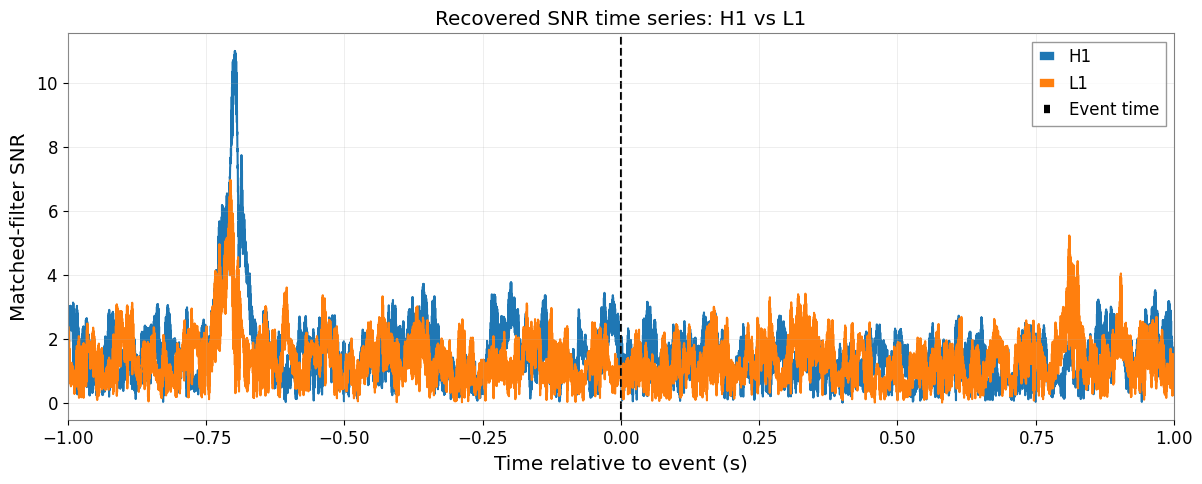

In [25]:
# ------------------------------------------------------------
# Overlay SNR time series for H1 and L1
# ------------------------------------------------------------
# This plot compares the matched-filter SNR time series
# for the best template in each detector.
#
# It shows:
#   - the signal peak in each detector
#   - the small time delay between detectors

plt.figure(figsize=(12,5))

for det in detectors:

    # Extract best template row for this detector
    row = detector_best[detector_best["detector"] == det].iloc[0]

    m1 = row["mass1"]
    m2 = row["mass2"]

    data = pycbc_data[det]
    psd = psd_data[det]

    # regenerate template for this detector
    hp, hc = get_td_waveform(
        approximant=approximant,
        mass1=m1,
        mass2=m2,
        delta_t=1.0/sample_rate,
        f_lower=f_low
    )

    template = hp.copy()
    template.resize(len(data))

    snr = matched_filter(
        template,
        data,
        psd=psd,
        low_frequency_cutoff=f_low
    )

    snr = snr.crop(crop_seconds, crop_seconds)

    times_rel = np.array(snr.sample_times) - event_time_gps

    plt.plot(times_rel, abs(snr), label=f"{det}")

plt.axvline(0, ls="--", color="black", label="Event time")

plt.xlabel("Time relative to event (s)")
plt.ylabel("Matched-filter SNR")
plt.title("Recovered SNR time series: H1 vs L1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlim(-1, 1)
plt.show()